# Notebook 07 — Multimodal Evaluation

This notebook evaluates the 7 multimodal experiments on the **fixed test set** and selects the best model.

## Structure
1. **Full evaluation of all 7 experiments** — test set metrics for each experiment
2. **Comparative analysis** — global metrics, melanoma & BCC recall, per-class heatmap
3. **Best model selection** — justified by clinical priorities
4. **In-depth analysis of the best model** — confusion matrix, ROC curves

## Key metrics
- **Recall Melanoma** — false negative = life risk
- **Recall BCC** — malignant, needs early detection
- **AUC macro** — global discriminative power
- **Recall macro** — fairness across all classes

## Other metrics
- F1 macro, F1 per class, Accuracy

## Unimodal baseline (reference)
| Metric | Value |
|--------|-------|
| Accuracy | 0.8163 |
| Recall macro | 0.7184 |
| F1 macro | 0.6999 |
| AUC macro | 0.9552 |
| Recall Melanoma | 0.7619 |
| Recall BCC | 0.6129 |

In [5]:
import sys
sys.path.append('../src')

import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from tqdm import tqdm

from config import (
    METRICS_DIR, FIGURES_DIR, MODELS_DIR, OUTPUTS_DIR,
    NUM_CLASSES, BATCH_SIZE, NUM_WORKERS,
    CLASS_NAMES_FULL, IDX_TO_CLASS, CLASSES
)
from dataset import load_test_multimodal, MultimodalSkinLesionDataset
from model import MultimodalModel
from transforms import get_val_transforms

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports OK')

Device: cuda
Imports OK


In [6]:
EXPERIMENTS = {
    'multimodal_b0_none_sex':                  ['sex'],
    'multimodal_b0_none_age':                  ['age'],
    'multimodal_b0_none_localization':         ['localization'],
    'multimodal_b0_none_sex_age':              ['sex', 'age'],
    'multimodal_b0_none_sex_localization':     ['sex', 'localization'],
    'multimodal_b0_none_age_localization':     ['age', 'localization'],
    'multimodal_b0_none_sex_age_localization': ['sex', 'age', 'localization'],
}

BASELINE = {
    'experiment':   'Baseline — B0 none (unimodal)',
    'accuracy':     0.8163,
    'recall_macro': 0.7184,
    'f1_macro':     0.6999,
    'auc_macro':    0.9552,
    'recall_mel':   0.7619,
    'recall_bcc':   0.6129,
}

def get_best_fold(exp_name):
    """Return the fold index with highest val AUC from record.json."""
    record_path = os.path.join(METRICS_DIR, f"{exp_name}_record.json")
    with open(record_path) as f:
        record = json.load(f)
    fold_aucs = record['results']['fold_aucs']
    return int(np.argmax(fold_aucs))

# Verify all records exist and print best fold per experiment
for exp_name in EXPERIMENTS:
    best_fold = get_best_fold(exp_name)
    print(f"{exp_name}  →  best fold: {best_fold}")

multimodal_b0_none_sex  →  best fold: 0
multimodal_b0_none_age  →  best fold: 0
multimodal_b0_none_localization  →  best fold: 0
multimodal_b0_none_sex_age  →  best fold: 0
multimodal_b0_none_sex_localization  →  best fold: 0
multimodal_b0_none_age_localization  →  best fold: 0
multimodal_b0_none_sex_age_localization  →  best fold: 0


In [7]:
def run_inference_multimodal(model, loader, device):
    """Run inference on a multimodal DataLoader."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, metadata, labels in tqdm(loader, desc="Inference", leave=False):
            images   = images.to(device)
            metadata = metadata.to(device)
            logits   = model(images, metadata)
            probs    = torch.softmax(logits, dim=1).cpu().numpy()
            preds    = np.argmax(probs, axis=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_metrics(labels, preds, probs):
    """Compute all metrics from inference results."""
    metrics = {
        'accuracy':     accuracy_score(labels, preds),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro':     f1_score(labels, preds, average='macro', zero_division=0),
        'auc_macro':    roc_auc_score(labels, probs, multi_class='ovr', average='macro'),
    }
    recall_per_class = recall_score(labels, preds, average=None, zero_division=0)
    f1_per_class     = f1_score(labels, preds, average=None, zero_division=0)

    for i in range(NUM_CLASSES):
        class_key = IDX_TO_CLASS[i]
        metrics[f'recall_{class_key}'] = recall_per_class[i]
        metrics[f'f1_{class_key}']     = f1_per_class[i]

    return metrics

print("Helper functions defined OK")

Helper functions defined OK


## Part 1 — Full Evaluation of All 7 Experiments

Each experiment is evaluated on the fixed test set using the best fold model (selected by Val AUC from K-Fold).

In [8]:
all_results = {}

for exp_name, metadata_cols in EXPERIMENTS.items():
    print(f"\nEvaluating: {exp_name}")
    
    # Get best fold model path
    best_fold  = get_best_fold(exp_name)
    model_path = os.path.join(MODELS_DIR, f"{exp_name}_fold{best_fold}.pth")
    
    # Load test dataset
    test_dataset = load_test_multimodal('none', metadata_cols, get_val_transforms())
    test_loader  = DataLoader(
        test_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
    
    # Load model
    metadata_dim = test_dataset.get_metadata_dim()
    model = MultimodalModel(metadata_dim=metadata_dim, efficientnet_version='b0', pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    
    # Inference
    labels, preds, probs = run_inference_multimodal(model, test_loader, device)
    
    # Metrics
    metrics = compute_metrics(labels, preds, probs)
    metrics['experiment'] = exp_name
    all_results[exp_name] = {
        'metrics': metrics,
        'labels':  labels,
        'preds':   preds,
        'probs':   probs,
    }
    
    print(f"  AUC macro:    {metrics['auc_macro']:.4f}")
    print(f"  Recall macro: {metrics['recall_macro']:.4f}")
    print(f"  Recall mel:   {metrics['recall_mel']:.4f}")
    print(f"  Recall bcc:   {metrics['recall_bcc']:.4f}")
    
    # Free GPU memory
    model.cpu()
    del model
    torch.cuda.empty_cache()

print("\nAll experiments evaluated!")


Evaluating: multimodal_b0_none_sex


/tmp/ipykernel_670825/2831814959.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_67082

  AUC macro:    0.9611
  Recall macro: 0.7327
  Recall mel:   0.7202
  Recall bcc:   0.7792

Evaluating: multimodal_b0_none_age


/tmp/ipykernel_670825/2831814959.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


  AUC macro:    0.9579
  Recall macro: 0.7048
  Recall mel:   0.7262
  Recall bcc:   0.8182

Evaluating: multimodal_b0_none_localization


...

/tmp/ipykernel_670825/2831814959.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


  AUC macro:    0.9618
  Recall macro: 0.7218
  Recall mel:   0.7143
  Recall bcc:   0.7403

Evaluating: multimodal_b0_none_age_localization


/tmp/ipykernel_670825/2831814959.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


  AUC macro:    0.9629
  Recall macro: 0.7181
  Recall mel:   0.7262
  Recall bcc:   0.7273

Evaluating: multimodal_b0_none_sex_age_localization


  AUC macro:    0.9590
  Recall macro: 0.7075
  Recall mel:   0.6786
  Recall bcc:   0.8052

All experiments evaluated!


## Part 2 — Comparative Analysis

In [9]:
rows = []
for exp_name, data in all_results.items():
    m = data['metrics']
    rows.append({
        'Experiment':     exp_name.replace('multimodal_b0_none_', ''),
        'Accuracy':       round(m['accuracy'], 4),
        'Recall macro':   round(m['recall_macro'], 4),
        'F1 macro':       round(m['f1_macro'], 4),
        'AUC macro':      round(m['auc_macro'], 4),
        'Recall mel':     round(m['recall_mel'], 4),
        'Recall bcc':     round(m['recall_bcc'], 4),
    })

# Add baseline
rows.append({
    'Experiment':   'BASELINE (unimodal)',
    'Accuracy':     BASELINE['accuracy'],
    'Recall macro': BASELINE['recall_macro'],
    'F1 macro':     BASELINE['f1_macro'],
    'AUC macro':    BASELINE['auc_macro'],
    'Recall mel':   BASELINE['recall_mel'],
    'Recall bcc':   BASELINE['recall_bcc'],
})

df_comparison = pd.DataFrame(rows)

# Highlight best value per column (excluding baseline row)
def highlight_best(s):
    is_best = s == s[:-1].max()  # exclude baseline from max
    return ['font-weight: bold; color: #2ecc71' if v else '' for v in is_best]

df_comparison.style\
    .apply(highlight_best, subset=['Accuracy', 'Recall macro', 'F1 macro', 'AUC macro', 'Recall mel', 'Recall bcc'])\
    .set_caption("Multimodal vs Unimodal Baseline — Test Set Metrics")

,Experiment,Accuracy,Recall macro,F1 macro,AUC macro,Recall mel,Recall bcc
0,sex,0.808300,0.732700,0.696500,0.961100,0.720200,0.779200
1,age,0.750200,0.704800,0.621200,0.957900,0.726200,0.818200
2,localization,0.796900,0.718700,0.687100,0.961300,0.797600,0.766200
3,sex_age,0.819000,0.749300,0.703300,0.961600,0.696400,0.844200
4,sex_localization,0.808300,0.721800,0.704100,0.961800,0.714300,0.740300
5,age_localization,0.808300,0.718100,0.694100,0.962900,0.726200,0.727300
6,sex_age_localization,0.804300,0.707500,0.695300,0.959000,0.678600,0.805200
7,BASELINE (unimodal),0.816300,0.718400,0.699900,0.955200,0.761900,0.612900


### Global Metrics Comparison

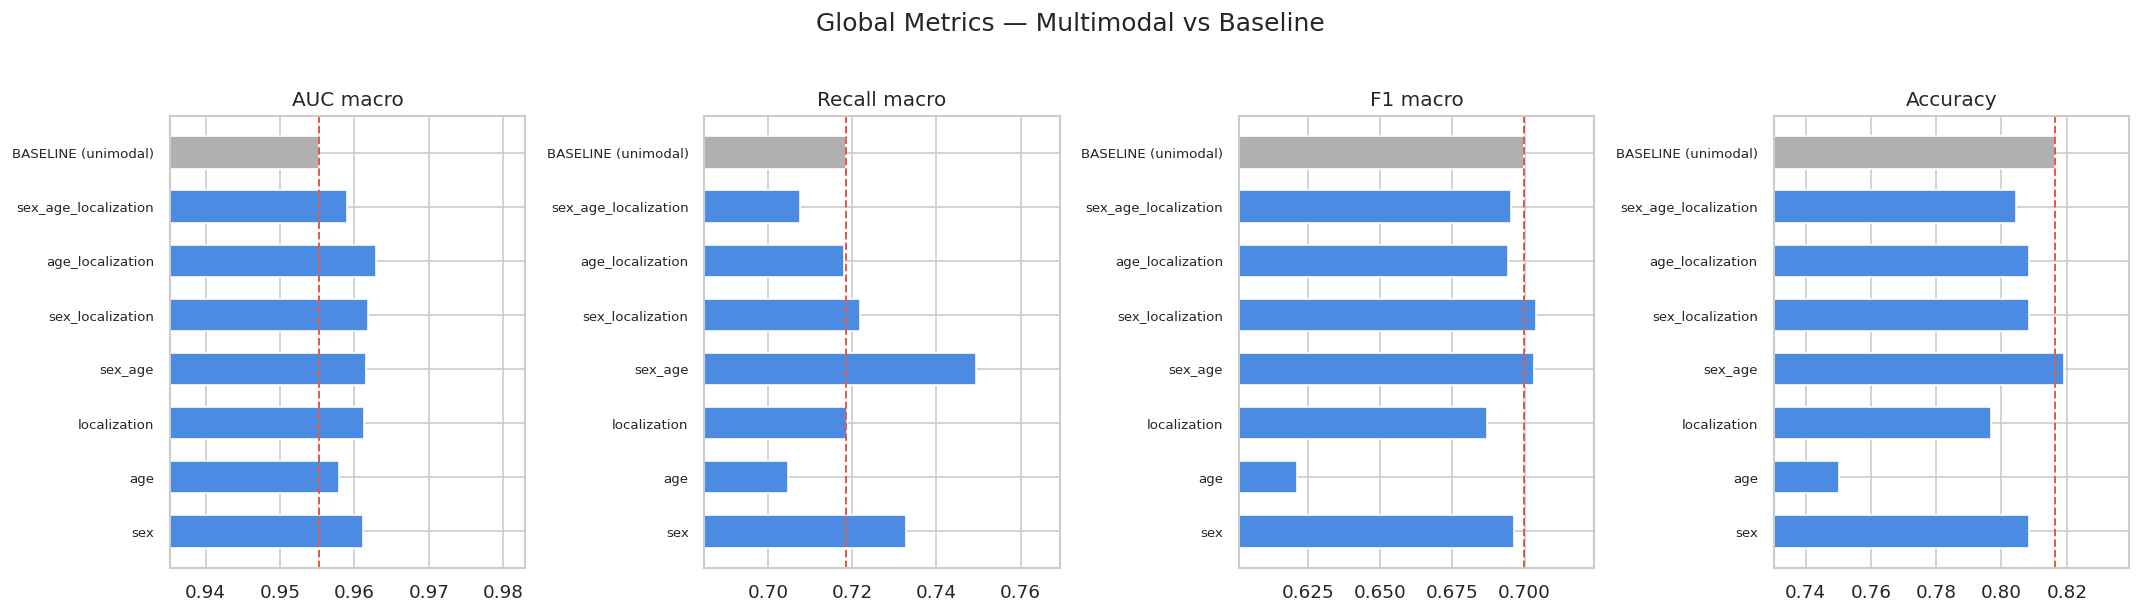

Saved: multimodal_global_metrics.png


In [10]:
metrics_to_plot = ['AUC macro', 'Recall macro', 'F1 macro', 'Accuracy']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    colors = ['#B0B0B0' if 'BASELINE' in row else '#4C8BE2' 
              for row in df_comparison['Experiment']]
    ax.barh(df_comparison['Experiment'], df_comparison[metric], 
            color=colors, edgecolor='white', height=0.6)
    ax.axvline(BASELINE[metric.lower().replace(' ', '_')], 
               color='#E25C4C', linestyle='--', linewidth=1.2)
    ax.set_title(metric)
    ax.set_xlim(df_comparison[metric].min() - 0.02, 
                df_comparison[metric].max() + 0.02)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Global Metrics — Multimodal vs Baseline', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'multimodal_global_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multimodal_global_metrics.png")

### Melanoma & BCC Recall

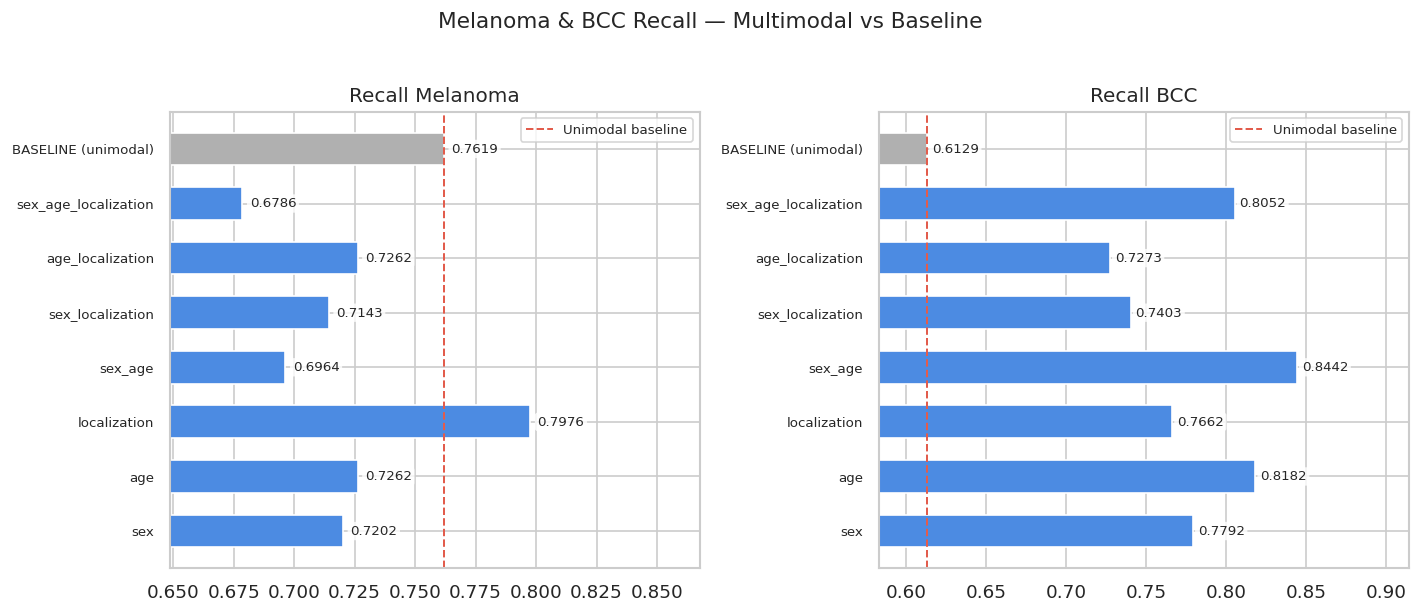

Saved: multimodal_melanoma_bcc_recall.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (metric, col, title) in zip(axes, [
    ('Recall mel', 'recall_mel', 'Recall Melanoma'),
    ('Recall bcc', 'recall_bcc', 'Recall BCC'),
]):
    colors = ['#B0B0B0' if 'BASELINE' in row else '#4C8BE2'
              for row in df_comparison['Experiment']]
    ax.barh(df_comparison['Experiment'], df_comparison[metric],
            color=colors, edgecolor='white', height=0.6)
    ax.axvline(BASELINE[col], color='#E25C4C', linestyle='--', 
               linewidth=1.2, label='Unimodal baseline')
    
    # Add value labels with white background
    for i, (_, row) in enumerate(df_comparison.iterrows()):
        ax.text(row[metric] + 0.003, i, f"{row[metric]:.4f}",
                va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                          edgecolor='none', alpha=0.8))
    
    ax.set_title(title, fontsize=12)
    ax.set_xlim(df_comparison[metric].min() - 0.03,
                df_comparison[metric].max() + 0.07)
    ax.legend(fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Melanoma & BCC Recall — Multimodal vs Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'multimodal_melanoma_bcc_recall.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multimodal_melanoma_bcc_recall.png")

### Per-Class Recall Heatmap

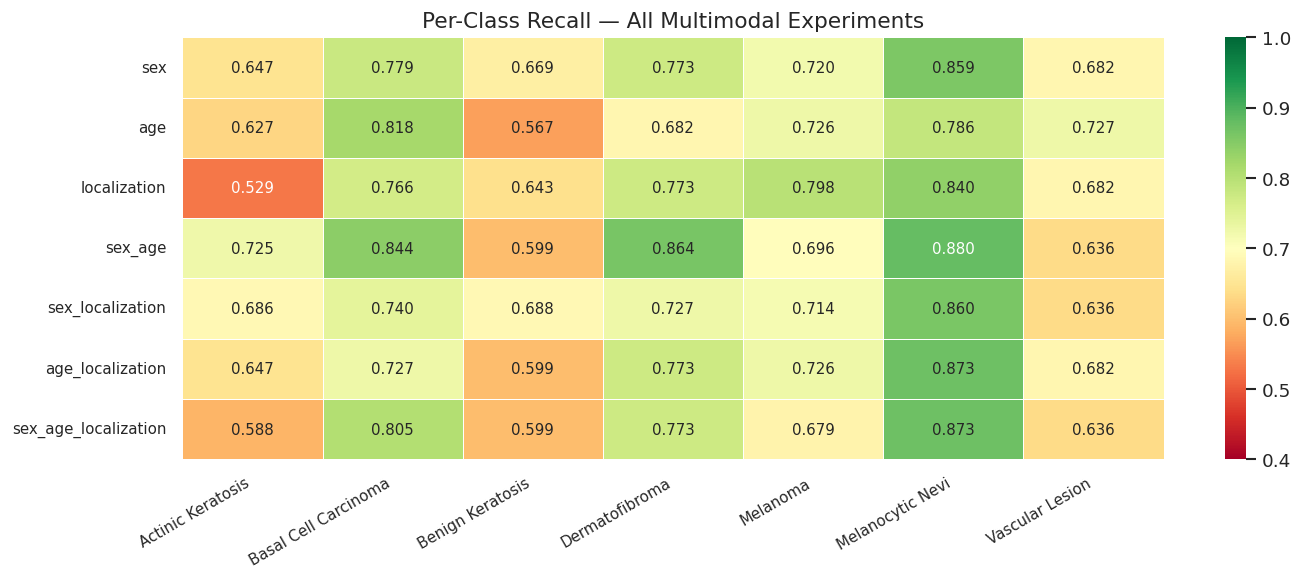

Saved: multimodal_perclass_recall_heatmap.png


In [12]:
recall_cols = [f'recall_{c}' for c in CLASSES]
class_labels = [CLASS_NAMES_FULL[c] for c in CLASSES]
exp_labels   = [e.replace('multimodal_b0_none_', '') for e in all_results.keys()]

# Build matrix (experiments × classes)
matrix = []
for exp_name in all_results.keys():
    m = all_results[exp_name]['metrics']
    matrix.append([m[f'recall_{c}'] for c in CLASSES])

df_heatmap = pd.DataFrame(matrix, index=exp_labels, columns=class_labels)

# Add baseline row
baseline_row = [BASELINE['recall_mel'] if c == 'mel' else 
                BASELINE['recall_bcc'] if c == 'bcc' else 
                np.nan for c in CLASSES]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    df_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.4, vmax=1.0, ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('Per-Class Recall — All Multimodal Experiments', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'multimodal_perclass_recall_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multimodal_perclass_recall_heatmap.png")

## Part 3 — Best Model Selection

Selection based on clinical priorities:
1. **Recall Melanoma** — highest priority (false negative = life risk)
2. **Recall BCC** — malignant, needs early detection
3. **AUC macro** — global discriminative power
4. **Recall macro** — fairness across all classes

In [13]:
df_ranking = df_comparison[df_comparison['Experiment'] != 'BASELINE (unimodal)'].copy()

# Rank each experiment per metric (1 = best)
df_ranking['rank_mel']    = df_ranking['Recall mel'].rank(ascending=False)
df_ranking['rank_bcc']    = df_ranking['Recall bcc'].rank(ascending=False)
df_ranking['rank_auc']    = df_ranking['AUC macro'].rank(ascending=False)
df_ranking['rank_recall'] = df_ranking['Recall macro'].rank(ascending=False)

# Weighted score (lower = better): mel x4, bcc x3, auc x2, recall x1
df_ranking['score'] = (
    df_ranking['rank_mel']    * 4 +
    df_ranking['rank_bcc']    * 3 +
    df_ranking['rank_auc']    * 2 +
    df_ranking['rank_recall'] * 1
)

df_ranking = df_ranking.sort_values('score')
print("Ranking by clinical priority score (lower = better):\n")
print(df_ranking[['Experiment', 'Recall mel', 'Recall bcc', 'AUC macro', 'Recall macro', 'score']].to_string(index=False))

best_exp    = df_ranking.iloc[0]['Experiment']
second_exp  = df_ranking.iloc[1]['Experiment']
print(f"\nBest model:   {best_exp}")
print(f"Second model: {second_exp}  (kept for selective ensemble)")

Ranking by clinical priority score (lower = better):

          Experiment  Recall mel  Recall bcc  AUC macro  Recall macro  score
        localization      0.7976      0.7662     0.9613        0.7187   31.0
             sex_age      0.6964      0.8442     0.9616        0.7493   34.0
                 age      0.7262      0.8182     0.9579        0.7048   37.0
    age_localization      0.7262      0.7273     0.9629        0.7181   38.0
                 sex      0.7202      0.7792     0.9611        0.7327   40.0
    sex_localization      0.7143      0.7403     0.9618        0.7218   45.0
sex_age_localization      0.6786      0.8052     0.9590        0.7075   55.0

Best model:   localization
Second model: sex_age  (kept for selective ensemble)


### Best vs Second Model — Key Metrics Comparison

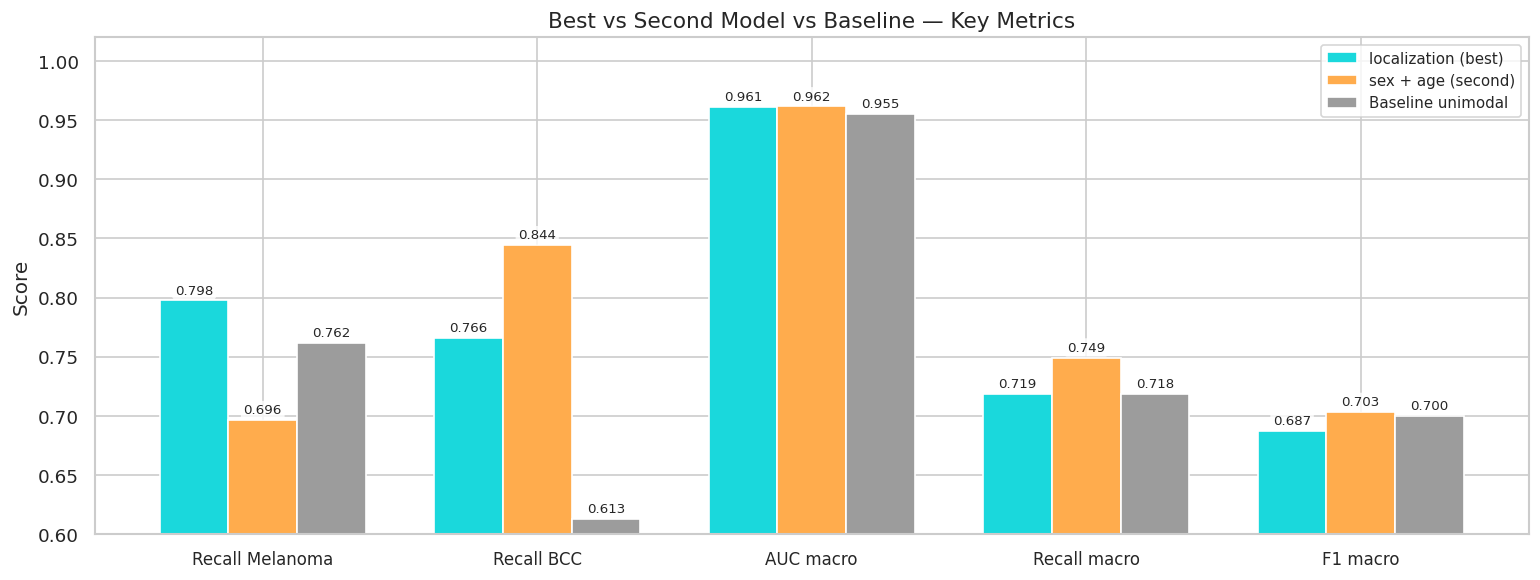

Saved: multimodal_best_vs_second.png


In [14]:
metrics_to_compare = {
    'Recall Melanoma': ('Recall mel', 'recall_mel'),
    'Recall BCC':      ('Recall bcc', 'recall_bcc'),
    'AUC macro':       ('AUC macro',  'auc_macro'),
    'Recall macro':    ('Recall macro', 'recall_macro'),
    'F1 macro':        ('F1 macro',   'f1_macro'),
}

loc_data      = df_comparison[df_comparison['Experiment'] == 'localization'].iloc[0]
sex_age_data  = df_comparison[df_comparison['Experiment'] == 'sex_age'].iloc[0]
baseline_data = df_comparison[df_comparison['Experiment'] == 'BASELINE (unimodal)'].iloc[0]

x     = np.arange(len(metrics_to_compare))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

bars1 = ax.bar(x - width, [loc_data[v[0]] for v in metrics_to_compare.values()],
               width, label='localization (best)', color="#1AD8DC", edgecolor='white')
bars2 = ax.bar(x,         [sex_age_data[v[0]] for v in metrics_to_compare.values()],
               width, label='sex + age (second)', color="#FFAC4D", edgecolor='white')
bars3 = ax.bar(x + width, [baseline_data[v[0]] for v in metrics_to_compare.values()],
               width, label='Baseline unimodal', color="#9C9C9C", edgecolor='white')

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_compare.keys(), fontsize=10)
ax.set_ylim(0.60, 1.02)
ax.set_ylabel('Score')
ax.set_title('Best vs Second Model vs Baseline — Key Metrics', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'multimodal_best_vs_second.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multimodal_best_vs_second.png")

### Decision

- **Best model: `localization`** — highest Recall Melanoma (0.7976), the top clinical priority
- **Second model: `sex_age`** — best Recall BCC (0.8442) and Recall macro (0.7493)
- Both models are kept for the **selective ensemble** (Part 5)

> Note: `age_localization` achieves the highest AUC macro (0.9629) but is outperformed by `localization` on Recall Melanoma, which takes precedence in a clinical setting.

## Part 4 — In-Depth Analysis of the Best Model

Detailed evaluation of the best model: **`localization`**

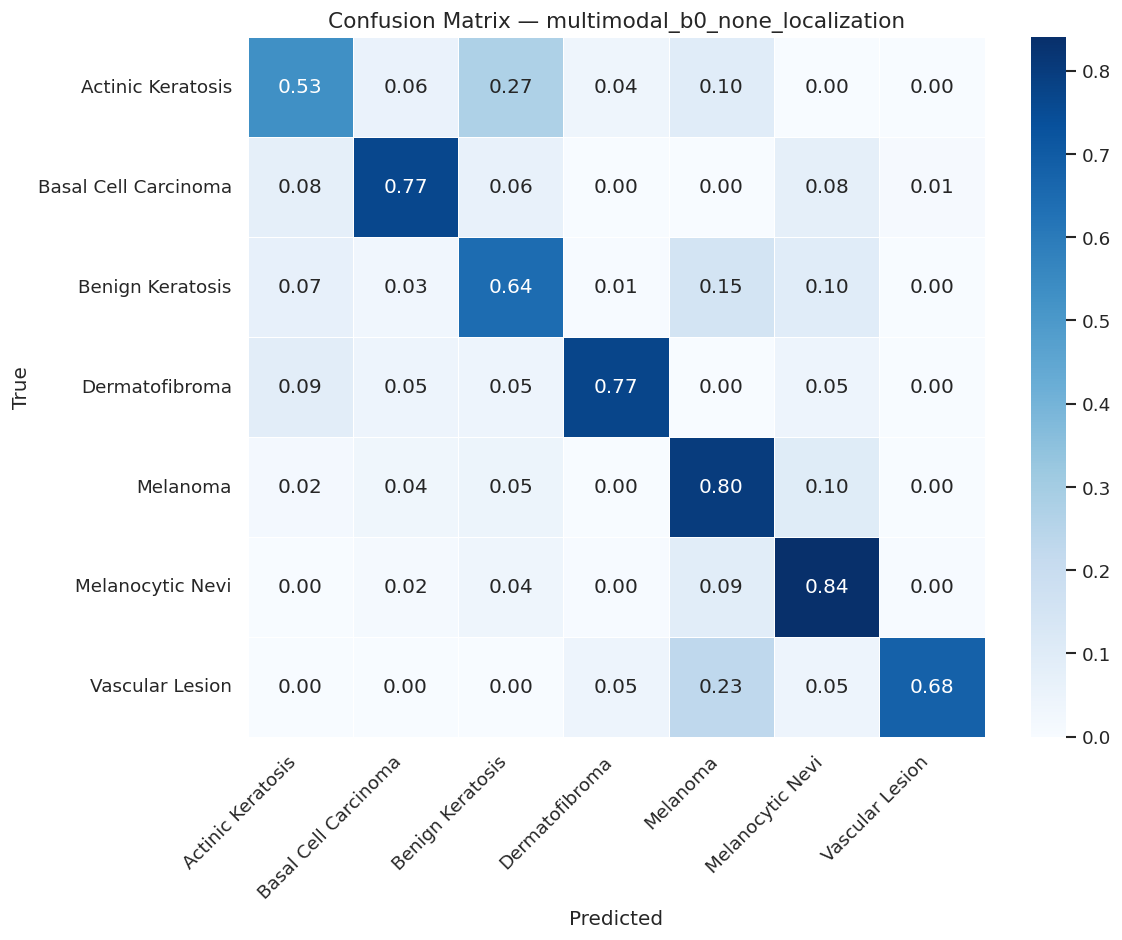

Saved: multimodal_b0_none_localization_confusion_matrix.png


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_data  = all_results[f'multimodal_b0_none_{best_exp}']
labels     = best_data['labels']
preds      = best_data['preds']
probs      = best_data['probs']

class_names = [CLASS_NAMES_FULL[c] for c in CLASSES]

cm = confusion_matrix(labels, preds, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, linewidths=0.5, linecolor='white'
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — multimodal_b0_none_{best_exp}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'multimodal_b0_none_{best_exp}_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: multimodal_b0_none_{best_exp}_confusion_matrix.png")

### ROC Curves

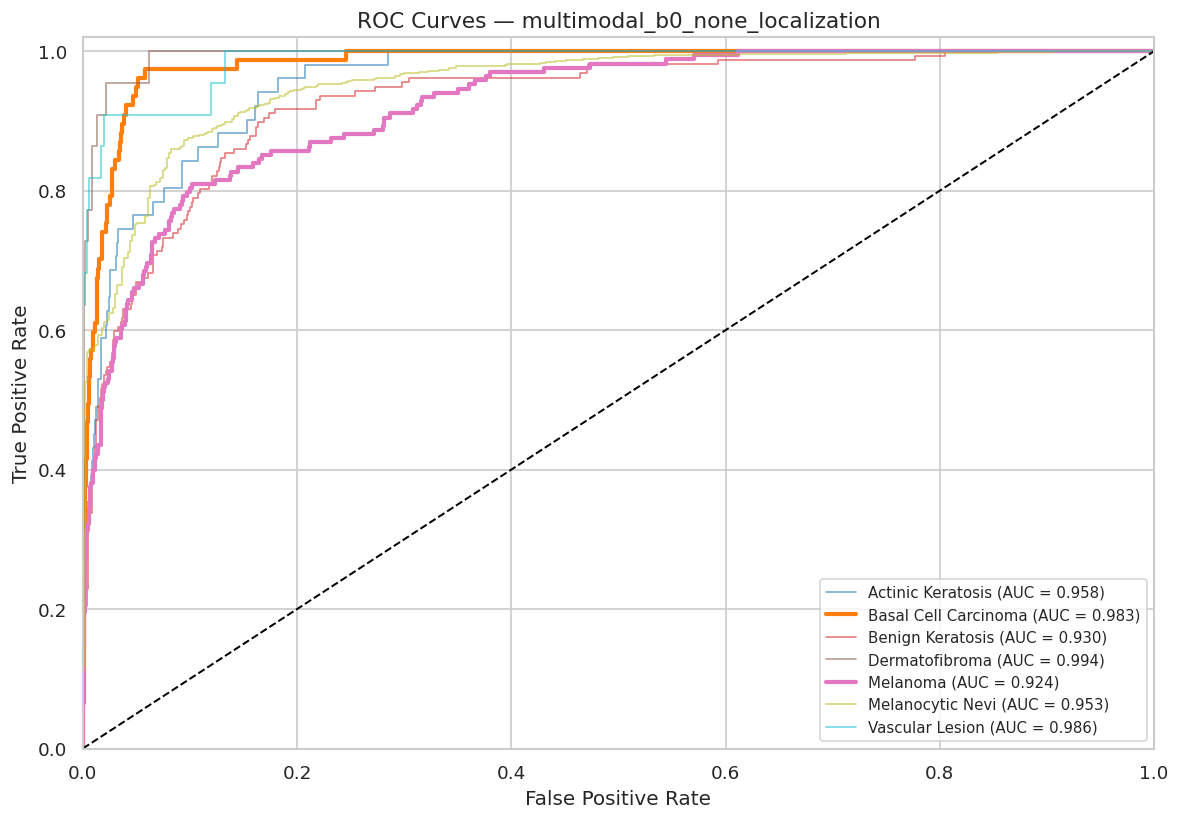

Saved: multimodal_b0_none_localization_roc_curves.png


In [16]:
from sklearn.metrics import roc_curve, auc

class_names = [CLASS_NAMES_FULL[c] for c in CLASSES]
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 7))

for i, (name, color) in enumerate(zip(class_names, colors)):
    binary_labels = (labels == i).astype(int)
    fpr, tpr, _   = roc_curve(binary_labels, probs[:, i])
    roc_auc       = auc(fpr, tpr)
    
    is_priority = CLASSES[i] in ['mel', 'bcc']
    ax.plot(fpr, tpr, color=color,
            lw=2.5 if is_priority else 1.0,
            alpha=1.0 if is_priority else 0.6,
            label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — multimodal_b0_none_{best_exp}', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'multimodal_b0_none_{best_exp}_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: multimodal_b0_none_{best_exp}_roc_curves.png")

## Saving Standard Probabilities

Standard inference probabilities for the two selected models are saved here for use in **Notebook 09 (Selective Ensemble)**.

| File | Location | Description |
|------|----------|-------------|
| `std_probs_localization.npy` | `outputs/metrics/` | Standard probabilities — localization model |
| `std_probs_sex_age.npy` | `outputs/metrics/` | Standard probabilities — sex_age model |
| `std_labels.npy` | `outputs/metrics/` | Ground truth labels (test set) |

In [19]:
for exp_key in ['localization', 'sex_age']:
    exp_name = f'multimodal_b0_none_{exp_key}'
    probs    = all_results[exp_name]['probs']
    np.save(os.path.join(METRICS_DIR, f'std_probs_{exp_key}.npy'), probs)

np.save(os.path.join(METRICS_DIR, 'std_labels.npy'), all_results['multimodal_b0_none_localization']['labels'])

print("Saved standard probabilities:")
print(f"    std_probs_localization.npy → {METRICS_DIR}")
print(f"    std_probs_sex_age.npy → {METRICS_DIR}")
print(f"    std_labels.npy → {METRICS_DIR}")

Saved standard probabilities:
    std_probs_localization.npy → /home/maialen/skin_lesion_PFG/outputs/metrics
    std_probs_sex_age.npy → /home/maialen/skin_lesion_PFG/outputs/metrics
    std_labels.npy → /home/maialen/skin_lesion_PFG/outputs/metrics


---
## Summary & Conclusions

### All multimodal experiments outperform the unimodal baseline
All 7 experiments improve over the unimodal baseline (AUC 0.9552) on AUC macro, confirming that clinical metadata adds discriminative value.

### Best model: `localization`
Selected as primary model based on clinical priorities:
- **Recall Melanoma: 0.7976** (+0.0357 vs baseline) — highest priority metric
- AUC macro: 0.9613 (+0.0061 vs baseline)

### Second model: `sex_age`
Kept for selective ensemble due to complementary strengths:
- **Recall BCC: 0.8442** (+0.2313 vs baseline) — best across all experiments
- **Recall macro: 0.7493** — best overall class fairness

### Key observations
- `localization` alone is the most informative single metadata feature for melanoma detection, consistent with clinical knowledge (certain body locations have higher melanoma risk)
- `sex_age` captures demographic patterns that complement visual features, particularly for BCC
- Adding all metadata (`sex_age_localization`) does not improve over simpler combinations — less is more
